## Classification (Safola Bhattarai) Week 5 Assignment 




In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('bank_transactions.csv')
df.head()


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


## Exercise 10: Loading Dataset

In [2]:
print('Shape:', df.shape)
df.info()


Shape: (1048567, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048567 entries, 0 to 1048566
Data columns (total 9 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   TransactionID            1048567 non-null  object 
 1   CustomerID               1048567 non-null  object 
 2   CustomerDOB              1045170 non-null  object 
 3   CustGender               1047467 non-null  object 
 4   CustLocation             1048416 non-null  object 
 5   CustAccountBalance       1046198 non-null  float64
 6   TransactionDate          1048567 non-null  object 
 7   TransactionTime          1048567 non-null  int64  
 8   TransactionAmount (INR)  1048567 non-null  float64
dtypes: float64(2), int64(1), object(6)
memory usage: 72.0+ MB


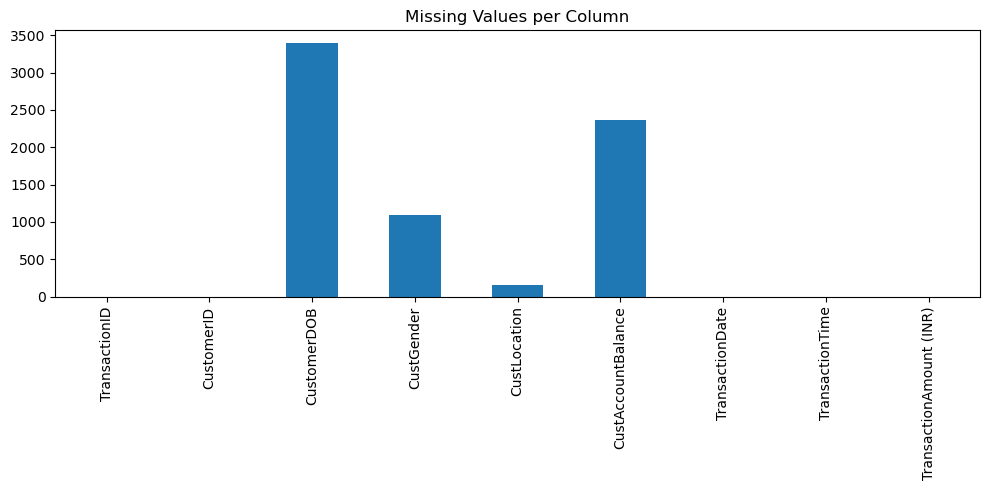

In [3]:
# Missing values visualization
missing = df.isnull().sum()

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title('Missing Values per Column')
plt.tight_layout()
plt.show()


## Exercise 11: Pre-Processing Data

In [19]:
from sklearn.preprocessing import LabelEncoder

df = df.copy()
df.fillna(-999, inplace=True)

df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

df['BirthYear'] = df['CustomerDOB'].dt.year.fillna(0)
df['TransactionYear'] = df['TransactionDate'].dt.year.fillna(0)

encoders = {}

for col in ['TransactionID','CustomerID','CustLocation','CustGender']:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

df.head()


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),BirthYear,TransactionYear
0,0,479739,1994-10-01,1,2876,17819.05,2016-02-08,143207,25.0,1994,2016
1,114879,32222,2057-04-04,2,2945,2270.69,2016-02-08,141858,27999.0,2057,2016
2,238337,303319,1996-11-26,1,4745,17874.44,2016-02-08,142712,459.0,1996,2016
3,361794,419888,2073-09-14,1,4745,866503.21,2016-02-08,142714,2060.0,2073,2016
4,485251,865804,1988-03-24,1,5177,6714.43,2016-02-08,181156,1762.5,1988,2016


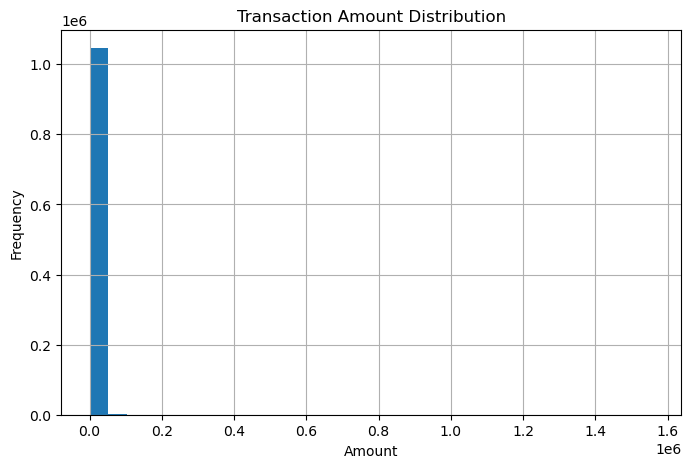

In [20]:
# Transaction Amount Distribution
plt.figure(figsize=(8,5))
df['TransactionAmount (INR)'].hist(bins=30)
plt.title('Transaction Amount Distribution')
plt.xlabel('Amount')
plt.ylabel('Frequency')
plt.show()


## Activity 7: Preparing Data for Classification

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
target = 'CustGender'
features = df.drop(columns=[target,'CustomerDOB','TransactionDate'])
labels = df[target]
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(features)
features_train, features_test, label_train, label_test = train_test_split(
    scaled_features,
    labels,
    test_size=0.20,
    random_state=42
)
print('Training:', features_train.shape)
print('Testing:', features_test.shape)

Training: (838853, 8)
Testing: (209714, 8)


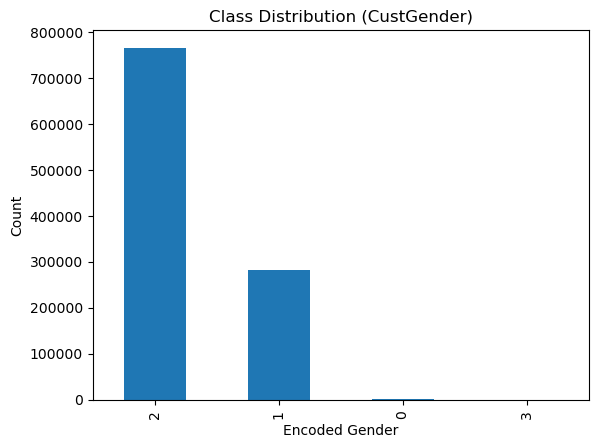

In [22]:
# Class Distribution
labels.value_counts().plot(kind='bar')
plt.title('Class Distribution (CustGender)')
plt.xlabel('Encoded Gender')
plt.ylabel('Count')
plt.show()

## Exercise 12 & 13: KNN Classification

In [23]:
from sklearn.neighbors import KNeighborsClassifier

classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(features_train, label_train)

accuracy = classifier.score(features_test, label_test)
print('Accuracy:', accuracy)


Accuracy: 0.6749191756392039


## Exercise 14: Prediction with KNN

In [9]:
predictions = classifier.predict(features_test[:10])

results = pd.DataFrame({
    'Actual': label_test.iloc[:10].values,
    'Predicted': predictions
})

print(results)
results


   Actual  Predicted
0       2          2
1       2          2
2       2          1
3       2          1
4       2          2
5       2          2
6       2          2
7       2          2
8       1          2
9       2          2


,Actual,Predicted
0,2,2
1,2,2
2,2,1
3,2,1
4,2,2
5,2,2
6,2,2
7,2,2
8,1,2
9,2,2


## Activity 8: Increasing Accuracy

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Load Data

In [2]:
df = pd.read_csv("bank_transactions.csv")
df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR)
0,T1,C5841053,10/1/94,F,JAMSHEDPUR,17819.05,2/8/16,143207,25.0
1,T2,C2142763,4/4/57,M,JHAJJAR,2270.69,2/8/16,141858,27999.0
2,T3,C4417068,26/11/96,F,MUMBAI,17874.44,2/8/16,142712,459.0
3,T4,C5342380,14/9/73,F,MUMBAI,866503.21,2/8/16,142714,2060.0
4,T5,C9031234,24/3/88,F,NAVI MUMBAI,6714.43,2/8/16,181156,1762.5


## Data Cleaning & Feature Engineering

In [3]:
df.fillna(-999, inplace=True)

df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')

df['BirthYear'] = df['CustomerDOB'].dt.year.fillna(0)
df['TransactionYear'] = df['TransactionDate'].dt.year.fillna(0)

df.head()

C:\Users\Asus\AppData\Local\Temp\ipykernel_8996\519987781.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['CustomerDOB'] = pd.to_datetime(df['CustomerDOB'], errors='coerce')
C:\Users\Asus\AppData\Local\Temp\ipykernel_8996\519987781.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['TransactionDate'] = pd.to_datetime(df['TransactionDate'], errors='coerce')


,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),BirthYear,TransactionYear
0,T1,C5841053,1994-10-01,F,JAMSHEDPUR,17819.05,2016-02-08,143207,25.0,1994,2016
1,T2,C2142763,2057-04-04,M,JHAJJAR,2270.69,2016-02-08,141858,27999.0,2057,2016
2,T3,C4417068,1996-11-26,F,MUMBAI,17874.44,2016-02-08,142712,459.0,1996,2016
3,T4,C5342380,2073-09-14,F,MUMBAI,866503.21,2016-02-08,142714,2060.0,2073,2016
4,T5,C9031234,1988-03-24,F,NAVI MUMBAI,6714.43,2016-02-08,181156,1762.5,1988,2016


## Encoding Categorical Variables

In [4]:
categorical_cols = ['TransactionID', 'CustomerID', 'CustLocation', 'CustGender']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

df.head()

,TransactionID,CustomerID,CustomerDOB,CustGender,CustLocation,CustAccountBalance,TransactionDate,TransactionTime,TransactionAmount (INR),BirthYear,TransactionYear
0,0,531762,1994-10-01,1,3587,17819.05,2016-02-08,143207,25.0,1994,2016
1,159679,128998,2057-04-04,2,3649,2270.69,2016-02-08,141858,27999.0,2057,2016
2,270790,372985,1996-11-26,1,5269,17874.44,2016-02-08,142712,459.0,1996,2016
3,381901,477898,2073-09-14,1,5269,866503.21,2016-02-08,142714,2060.0,2073,2016
4,493012,879221,1988-03-24,1,5658,6714.43,2016-02-08,181156,1762.5,1988,2016


## Define Features and Target

In [5]:
target = "CustGender"

X = df.drop(columns=[target, 'CustomerDOB', 'TransactionDate'])
y = df[target]

X.head(), y.head()

(   TransactionID  CustomerID  CustLocation  CustAccountBalance  \
 0              0      531762          3587            17819.05   
 1         159679      128998          3649             2270.69   
 2         270790      372985          5269            17874.44   
 3         381901      477898          5269           866503.21   
 4         493012      879221          5658             6714.43   
 
    TransactionTime  TransactionAmount (INR)  BirthYear  TransactionYear  
 0           143207                     25.0       1994             2016  
 1           141858                  27999.0       2057             2016  
 2           142712                    459.0       1996             2016  
 3           142714                   2060.0       2073             2016  
 4           181156                   1762.5       1988             2016  ,
 0    1
 1    2
 2    1
 3    1
 4    1
 Name: CustGender, dtype: int64)

## 10K Sample

In [6]:
sample_size = min(10000, len(df))

sample_df = df.sample(n=sample_size, random_state=42)

X_sample = sample_df.drop(columns=[target, 'CustomerDOB', 'TransactionDate'])
y_sample = sample_df[target]

X_sample.shape

(10000, 8)

## Train Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample,
    y_sample,
    test_size=0.20,
    random_state=42,
    stratify=y_sample
)

X_train.shape, X_test.shape

((8000, 8), (2000, 8))

## Baseline Model

In [8]:
baseline_pipeline = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

baseline_pipeline.fit(X_train, y_train)
baseline_pred = baseline_pipeline.predict(X_test)

print("========== BASELINE MODEL ==========\n")

print("Accuracy:", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred, average='weighted'))
print("Recall:", recall_score(y_test, baseline_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, baseline_pred, average='weighted'))

print("\nClassification Report:\n")
print(classification_report(y_test, baseline_pred))

========== BASELINE MODEL ==========

Accuracy: 0.6875
Precision: 0.6273776887871854
Recall: 0.6875
F1 Score: 0.6460607788133804

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.30      0.14      0.19       521
           2       0.74      0.88      0.81      1477

    accuracy                           0.69      2000
   macro avg       0.35      0.34      0.33      2000
weighted avg       0.63      0.69      0.65      2000



## K Sweep (Find Best K)

In [9]:
k_values = range(1, 51)
accuracy_scores = []

for k in k_values:
    model = Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    accuracy_scores.append(accuracy_score(y_test, pred))

best_k = k_values[np.argmax(accuracy_scores)]

print("Best K =", best_k)

Best K = 32


## K Sweep Plot

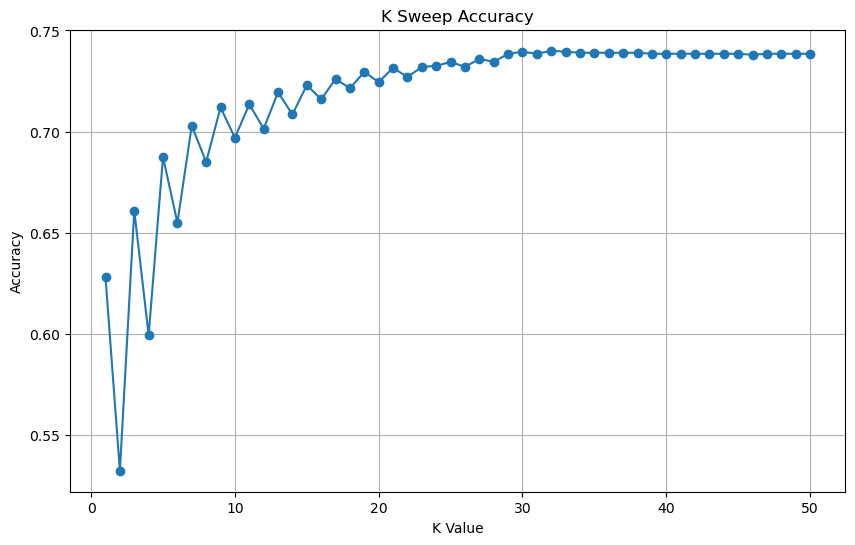

In [10]:
plt.figure(figsize=(10,6))
plt.plot(k_values, accuracy_scores, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Sweep Accuracy")
plt.grid()
plt.show()

## Weight Strategy Comparison

In [11]:
weight_results = {}

for weight in ['uniform', 'distance']:
    model = Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=best_k, weights=weight))
    ])
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    weight_results[weight] = accuracy_score(y_test, pred)

weight_results

{'uniform': 0.74, 'distance': 0.7375}

## Weight Plot

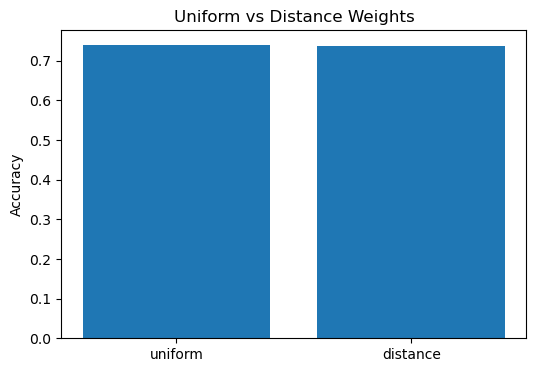

In [12]:
plt.figure(figsize=(6,4))
plt.bar(weight_results.keys(), weight_results.values())
plt.title("Uniform vs Distance Weights")
plt.ylabel("Accuracy")
plt.show()

## Distance Metric Comparison

In [13]:
metrics = {
    'euclidean': 2,
    'manhattan': 1,
    'minkowski': 3
}

metric_scores = {}

for name, p in metrics.items():
    model = Pipeline([
        ('scaler', MinMaxScaler()),
        ('knn', KNeighborsClassifier(
            n_neighbors=best_k,
            weights='distance',
            metric='minkowski',
            p=p
        ))
    ])
    
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    metric_scores[name] = accuracy_score(y_test, pred)

metric_scores

{'euclidean': 0.7375, 'manhattan': 0.7355, 'minkowski': 0.7365}

## Metric Plot

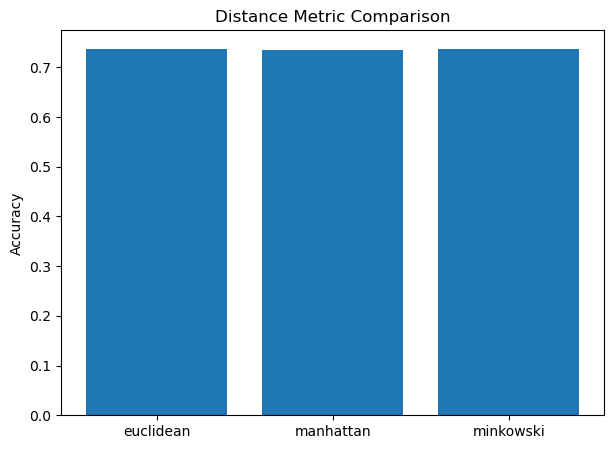

In [14]:
plt.figure(figsize=(7,5))
plt.bar(metric_scores.keys(), metric_scores.values())
plt.title("Distance Metric Comparison")
plt.ylabel("Accuracy")
plt.show()

## Best Model Selection

In [15]:
best_metric = max(metric_scores, key=metric_scores.get)
metric_p = metrics[best_metric]

best_model = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(
        n_neighbors=best_k,
        weights='distance',
        metric='minkowski',
        p=metric_p
    ))
])

best_model.fit(X_train, y_train)
best_pred = best_model.predict(X_test)

## Best Model Results

In [16]:
print("========== BEST MODEL ==========\n")

print("Accuracy:", accuracy_score(y_test, best_pred))
print("Precision:", precision_score(y_test, best_pred, average='weighted'))
print("Recall:", recall_score(y_test, best_pred, average='weighted'))
print("F1 Score:", f1_score(y_test, best_pred, average='weighted'))

========== BEST MODEL ==========

Accuracy: 0.7375
Precision: 0.643406375502008
Recall: 0.7375
F1 Score: 0.6296897135362032


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Confusion Matrix (Baseline vs Best)

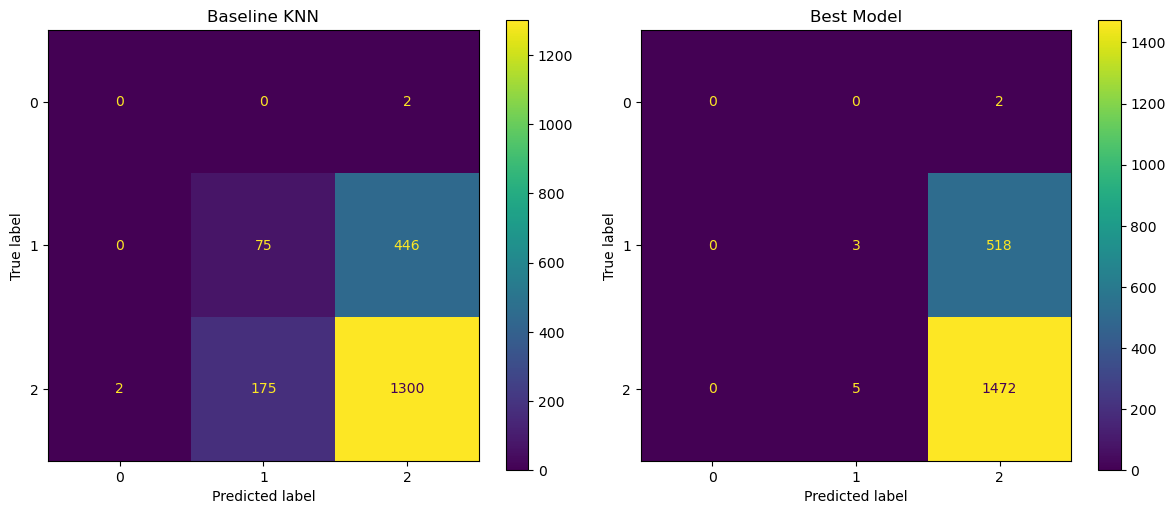

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))

ConfusionMatrixDisplay(confusion_matrix(y_test, baseline_pred)).plot(ax=ax[0])
ax[0].set_title("Baseline KNN")

ConfusionMatrixDisplay(confusion_matrix(y_test, best_pred)).plot(ax=ax[1])
ax[1].set_title("Best Model")

plt.tight_layout()
plt.show()